In [1]:
!pip install fastai joblib pandas numpy scikit-learn xgboost --quiet

# Machine Learning Project {`predict Freight Value - shipping costs`}

In [1]:
import pandas as pd, numpy as np
from glob import glob
import time
import os



from pandas.api.types import is_string_dtype, is_numeric_dtype, is_categorical_dtype
from fastai.tabular.all import *
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from IPython.display import Image, display_svg, SVG
from fastai.imports import *

pd.options.display.max_rows = 20
pd.options.display.max_columns = 8
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 150)
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

# Load Dataset 

In [2]:
df = pd.read_csv('items.csv')

df = df.drop(columns=['Unnamed: 0'])

# Chose "To Keep" Columns

the goal is to predict `freight_value`, what shall be the columns that i use ? and keep ? 


In [3]:
df.head(1)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,total_order_price_value,total_order_freight_value,total_order_value,seller_city,seller_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_city,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29,58.9,13.29,72.19,volta redonda,SP,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00,campos dos goytacazes,RJ


In [4]:
df.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'total_order_price_value', 'total_order_freight_value',
       'total_order_value', 'seller_city', 'seller_state',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_city', 'customer_state'],
      dtype='object')

the columns we decided to keep : 

the following columns, may cause data leakage: 
    - total order 

order_estimated_delivery_date -> the model may predict the correct number of days 
most products will be delivered at but for safety purposes the company will add 10 days extra puting into to consideration 
the things we can't control in life. such as accidents

In [5]:
to_keep = [
    "price",
    "product_weight_g",
    
    'total_order_price_value', 
    'total_order_freight_value',
    'total_order_value',
   
    "product_length_cm",
    "product_height_cm",
    "product_width_cm",
    
    'order_item_id', # new
    "product_category_name",
    
    "seller_state",
    "customer_state",
    "seller_city",
    "customer_city",
    
    "order_purchase_timestamp",
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    # "order_estimated_delivery_date", remove this and keep the actual date to be able to predict an estimation 😆
    'freight_value'
]

df = df[to_keep]

In [6]:
df.describe()

,price,product_weight_g,total_order_price_value,total_order_freight_value,total_order_value,product_length_cm,product_height_cm,product_width_cm,order_item_id,freight_value
count,112650.000000,112632.000000,112650.000000,112650.000000,112650.000000,112632.000000,112632.000000,112632.000000,112650.000000,112650.000000
mean,120.653739,2093.672047,136.686539,23.617636,160.304175,30.153669,16.593766,22.996546,1.197834,19.990320
std,183.633928,3751.596884,217.468683,25.118779,228.532489,16.153449,13.443483,11.707268,0.705124,15.806405
min,0.850000,0.000000,0.850000,0.000000,6.080000,7.000000,2.000000,6.000000,1.000000,0.000000
25%,39.900000,300.000000,45.000000,13.740000,61.070000,18.000000,8.000000,15.000000,1.000000,13.080000
50%,74.990000,700.000000,84.495000,17.250000,103.550000,25.000000,13.000000,20.000000,1.000000,16.260000
75%,134.900000,1800.000000,149.900000,24.960000,175.870000,38.000000,20.000000,30.000000,1.000000,21.150000
max,6735.000000,40425.000000,13440.000000,1794.960000,13664.080000,105.000000,105.000000,118.000000,21.000000,409.680000


# Make Functions for cleaning the data, to prepare for the one prediction at a time

## handle null values

In [7]:
df.isna().sum()

price                               0
product_weight_g                   18
total_order_price_value             0
total_order_freight_value           0
total_order_value                   0
product_length_cm                  18
product_height_cm                  18
product_width_cm                   18
order_item_id                       0
product_category_name            1627
seller_state                        0
customer_state                      0
seller_city                         0
customer_city                       0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1194
order_delivered_customer_date    2454
freight_value                       0
dtype: int64

In [8]:
df.shape

(112650, 19)

dropping 1627 values won't really affect us in terms of data!

In [9]:


df = df.dropna(subset=['product_category_name','product_weight_g','product_length_cm'
                       ,'product_height_cm' ,'product_width_cm','order_approved_at','order_delivered_carrier_date',
                       'order_delivered_customer_date'
                      ])

In [10]:
df.isna().sum()

price                            0
product_weight_g                 0
total_order_price_value          0
total_order_freight_value        0
total_order_value                0
product_length_cm                0
product_height_cm                0
product_width_cm                 0
order_item_id                    0
product_category_name            0
seller_state                     0
customer_state                   0
seller_city                      0
customer_city                    0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
freight_value                    0
dtype: int64

In [11]:
df.shape[0]

108621

cool we have 108621 rows of data to experiment with ! 😆

# Function that really makes my life easier 😍😆 

In [12]:
def make_new_columns(df):
    df['shipping_duration_days'] =  (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
    df['product_volume_cm3'] =  df['product_length_cm'] * df['product_weight_g'] *  df['product_height_cm']
    
    return df

def load_df_and_clean():
    df = pd.read_csv('items.csv')
    df = df.drop(columns=['Unnamed: 0'])
    to_keep = [
        "price",
        "product_weight_g",

        'total_order_price_value', 
        'total_order_freight_value',
        'total_order_value',

        "product_length_cm",
        "product_height_cm",
        "product_width_cm",

        'order_item_id', # new
        "product_category_name",

        "seller_state",
        "customer_state",
        "seller_city",
        "customer_city",

        "order_purchase_timestamp",
        'order_approved_at',
        'order_delivered_carrier_date',
        'order_delivered_customer_date',
        'freight_value'
    ]

    df = df[to_keep]
    
    # remove the rows that contain null values in any of the following columns
   
    df = df.dropna(subset=['product_category_name','product_weight_g','product_length_cm'
                       ,'product_height_cm' ,'product_width_cm','order_approved_at','order_delivered_carrier_date',
                       'order_delivered_customer_date'
                      ])
    
    
    df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
    df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
    df['order_approved_at'] = pd.to_datetime(df['order_approved_at'])
    df['order_delivered_carrier_date'] = pd.to_datetime(df['order_delivered_carrier_date'])
    
    df['purchase_date'] = df['order_purchase_timestamp'].dt.date
    df['purchase_time'] = df['order_purchase_timestamp'].dt.hour
    
    
    df = make_new_columns(df)
    
    # i will drop the following: 
        # - order_delivered_customer_date
        # - order_approved_at
        # - order_delivered_carrier_date
    # why ? because i the user, mainly the customer won't know the estimated time 
    
    df = df.drop(columns=['order_purchase_timestamp','order_delivered_customer_date', 'total_order_price_value', 
        'total_order_freight_value','order_approved_at',
        'order_delivered_carrier_date'])
    return df
    
    

# Load and Transform ! ☕️

In [173]:
df = load_df_and_clean().copy()
df.isna().sum()

price                     0
product_weight_g          0
total_order_value         0
product_length_cm         0
product_height_cm         0
product_width_cm          0
order_item_id             0
product_category_name     0
seller_state              0
customer_state            0
seller_city               0
customer_city             0
freight_value             0
purchase_date             0
purchase_time             0
shipping_duration_days    0
product_volume_cm3        0
dtype: int64

In [174]:
df

,price,product_weight_g,total_order_value,product_length_cm,product_height_cm,product_width_cm,order_item_id,product_category_name,seller_state,customer_state,seller_city,customer_city,freight_value,purchase_date,purchase_time,shipping_duration_days,product_volume_cm3
0,58.90,650.0,72.19,28.0,9.0,14.0,1,cool_stuff,SP,RJ,volta redonda,campos dos goytacazes,13.29,2017-09-13,8,7,163800.0
1,239.90,30000.0,259.83,50.0,30.0,40.0,1,pet_shop,SP,SP,sao paulo,santa fe do sul,19.93,2017-04-26,10,16,45000000.0
2,199.00,3050.0,216.87,33.0,13.0,33.0,1,furniture_decor,MG,MG,borda da mata,para de minas,17.87,2018-01-14,14,7,1308450.0
3,12.99,200.0,25.78,16.0,10.0,15.0,1,perfumery,SP,SP,franca,atibaia,12.79,2018-08-08,10,6,32000.0
4,199.90,3750.0,218.04,35.0,40.0,30.0,1,garden_tools,PR,SP,loanda,varzea paulista,18.14,2017-02-04,13,25,5250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112645,299.99,10150.0,343.40,89.0,15.0,40.0,1,housewares,SC,MA,itajai,sao luis,43.41,2018-04-23,13,17,13550250.0
112646,350.00,8950.0,386.53,45.0,26.0,38.0,1,computers_accessories,SP,PR,sao paulo,curitiba,36.53,2018-07-14,10,9,10471500.0
112647,99.90,967.0,116.85,21.0,24.0,19.0,1,sports_leisure,PR,SP,curitiba,sao paulo,16.95,2017-10-23,17,4,487368.0
112648,55.99,100.0,64.71,20.0,20.0,20.0,1,computers_accessories,SP,SP,sao paulo,vinhedo,8.72,2017-08-14,23,1,40000.0


In [14]:
# make a log transformation quickly and efficiently
def log_transform(df,col):
    df[col]= np.log1p(df[col])
    print('Log Transform successful ✅')    
    return df
    
def set_range_col(df,col,l,r):
    # very cool state of the pledged money raised
    df =  df[(df[col] >= l) & (df[col] <= r)]
    print( df[(df[col] >= l) & (df[col] <= r)][col].skew())
    print('Range successful ✅')    
    return df

def deal_with_outliers(df,col):
    Q1 = df[col].quantile(0.25)  # 25th percentile
    Q3 = df[col].quantile(0.75)  # 75th percentile
    IQR = Q3 - Q1                      # Interquartile range

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    upper_bound = np.ceil(upper_bound)
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    df.loc[df[col] > upper_bound, col] = upper_bound
    print('Outliers successful ✅')
    return df
    
# •  shipping_duration = order_estimated_delivery_date - order_purchase_timestamp
# •  product_volume_cm3 = length × width × height
# •  Encode product_category_name, seller_state, customer_state (one-hot or label encoding)
    


In [15]:
df.columns

Index(['price', 'product_weight_g', 'total_order_value', 'product_length_cm',
       'product_height_cm', 'product_width_cm', 'order_item_id',
       'product_category_name', 'seller_state', 'customer_state',
       'seller_city', 'customer_city', 'freight_value', 'purchase_date',
       'purchase_time', 'shipping_duration_days', 'product_volume_cm3'],
      dtype='object')

In [104]:
df = load_df_and_clean().copy()

In [105]:

df = deal_with_outliers(df,'total_order_value')
df = deal_with_outliers(df,'price')
df = deal_with_outliers(df,'freight_value')
df = deal_with_outliers(df,'order_item_id')





df = deal_with_outliers(df,'product_weight_g')
df = deal_with_outliers(df,'product_length_cm')
df = deal_with_outliers(df,'product_height_cm')
df = deal_with_outliers(df,'product_width_cm')

df = deal_with_outliers(df,'shipping_duration_days')
df = deal_with_outliers(df,'product_volume_cm3')





df = log_transform(df,'price')
df = log_transform(df,'freight_value')
df = log_transform(df,'order_item_id')

df = log_transform(df,'total_order_value')

df = log_transform(df,'product_weight_g')
df = log_transform(df,'product_length_cm')
df = log_transform(df,'product_height_cm')
df = log_transform(df,'product_width_cm')

df = log_transform(df,'shipping_duration_days')
df = log_transform(df,'product_volume_cm3')




Outliers successful ✅
Outliers successful ✅
Outliers successful ✅
Outliers successful ✅
Outliers successful ✅
Outliers successful ✅
Outliers successful ✅
Outliers successful ✅
Outliers successful ✅
Outliers successful ✅
Log Transform successful ✅
Log Transform successful ✅
Log Transform successful ✅
Log Transform successful ✅
Log Transform successful ✅
Log Transform successful ✅
Log Transform successful ✅
Log Transform successful ✅
Log Transform successful ✅
Log Transform successful ✅


In [18]:
df.describe()

,price,product_weight_g,total_order_value,product_length_cm,product_height_cm,product_width_cm,order_item_id,freight_value,purchase_time,shipping_duration_days,product_volume_cm3
count,108621.000000,108621.000000,108621.000000,108621.000000,108621.000000,108621.000000,1.086210e+05,108621.000000,108621.000000,108621.000000,108621.000000
mean,4.293649,6.588680,4.651421,3.327624,2.605365,3.077519,6.931472e-01,2.852966,14.752313,2.350582,12.316673
std,0.816998,1.141236,0.711248,0.424181,0.657340,0.416627,1.110228e-16,0.443703,5.313511,0.608342,1.811880
min,0.615186,0.000000,1.957274,2.079442,1.098612,1.945910,6.931472e-01,0.000000,0.000000,0.000000,0.000000
25%,3.711130,5.707110,4.128907,2.944439,2.197225,2.772589,6.931472e-01,2.644755,11.000000,1.945910,10.890293
50%,4.329417,6.552508,4.647942,3.258097,2.639057,3.044522,6.931472e-01,2.850128,15.000000,2.397895,12.355049
75%,4.911919,7.496097,5.175358,3.663562,3.044522,3.433987,6.931472e-01,3.098289,19.000000,2.772589,13.913092
max,5.631212,8.306719,5.855072,4.234107,3.663562,3.988984,6.931472e-01,3.555348,23.000000,3.401197,14.799749


remove the products where their weights = 0 !

In [106]:
f = df['product_weight_g'] != 0 
df = df[f]

### fixing the std for the `product_weight_g`

f = df.product_weight_g >= 4.3
f1 = df.product_weight_g < 8

df = df[f & f1]

### fixing the std for the `total_order_value`

f = df.total_order_value >= 3.1
f1 = df.total_order_value < 5.8

df[f & f1].total_order_value.hist(),df[f & f1].total_order_value.skew()

df = df[f & f1]

### fixing the std for the `product_length_cm`

f = df.product_length_cm >= 2.7
f1 = df.product_length_cm <= 4

df[f & f1].product_length_cm.hist(),df[f & f1].product_length_cm.shape

df = df[f & f1]

### fixing the std for the `product_length_cm`

In [20]:
df.shape

(108613, 17)

In [21]:
df.describe()

,price,product_weight_g,total_order_value,product_length_cm,product_height_cm,product_width_cm,order_item_id,freight_value,purchase_time,shipping_duration_days,product_volume_cm3
count,108613.000000,108613.000000,108613.000000,108613.000000,108613.000000,108613.000000,108613.000000,108613.000000,108613.000000,108613.000000,108613.000000
mean,4.293614,6.589165,4.651387,3.327616,2.605317,3.077493,0.693147,2.852946,14.752286,2.350578,12.317580
std,0.817017,1.139876,0.711258,0.424196,0.657341,0.416631,0.000000,0.443711,5.313589,0.608360,1.808860
min,0.615186,1.098612,1.957274,2.079442,1.098612,1.945910,0.693147,0.000000,0.000000,0.000000,5.493061
25%,3.711130,5.707110,4.128907,2.944439,2.197225,2.772589,0.693147,2.644755,11.000000,1.945910,10.890293
50%,4.329417,6.552508,4.647942,3.258097,2.639057,3.044522,0.693147,2.850128,15.000000,2.397895,12.355049
75%,4.911919,7.496097,5.175358,3.663562,3.044522,3.433987,0.693147,3.098289,19.000000,2.772589,13.913092
max,5.631212,8.306719,5.855072,4.234107,3.663562,3.988984,0.693147,3.555348,23.000000,3.401197,14.799749


# Machine Learning YYOOOOOO-WHHHHHHHHHOOOOOO 

#### Splitting the data

In [110]:
def train_test_split(df):
    total = df.shape[0]
    testing_portion = int(total * 0.10) # 10% test
    
    # the splits
    training_data = total - testing_portion
    test_data = training_data + testing_portion


    df1 = df[:training_data]
    df_test = df[training_data:test_data]
    return df1, df_test

In [111]:
df.shape

(108613, 17)

In [112]:
df, test_df = train_test_split(df)

In [113]:
# confirming results
df.shape[0] +test_df.shape[0]


108613

In [114]:
save_pickle('./test_df.pkl',test_df)

## Splitting the Data

In [115]:
# 20% validation set
splits = RandomSplitter(valid_pct=0.2,seed=42)(df)
len(splits[0]),len(splits[1]),len(df),len(splits[0])+len(splits[1])

(78202, 19550, 97752, 97752)

# Process the data

In [116]:
df.columns 

Index(['price', 'product_weight_g', 'total_order_value', 'product_length_cm',
       'product_height_cm', 'product_width_cm', 'order_item_id',
       'product_category_name', 'seller_state', 'customer_state',
       'seller_city', 'customer_city', 'freight_value', 'purchase_date',
       'purchase_time', 'shipping_duration_days', 'product_volume_cm3'],
      dtype='object')

In [117]:
dep_var = 'shipping_duration_days'

In [30]:
procs = [Categorify]

# 🔹 9000 is actually the max_card parameter — short for maximum cardinality.
# 🔹 It means: any column with fewer than or equal to 9000 unique values will be treated as categorical, otherwise it’s considered continuous.
cont, cat = cont_cat_split(df,9000,dep_var=dep_var)

In [31]:
to = TabularPandas(df, procs,cat, cont,y_names=dep_var,splits=splits)

## Save your Work 😉🚀 

In [32]:
save_pickle('./to_olist.pkl',to)

In [33]:
# good idea to understand functions correctly
cont_cat_split?


Signature: cont_cat_split(df, max_card=20, dep_var=None)
Docstring: Helper function that returns column names of cont and cat variables from given `df`.
File:      /usr/local/lib/python3.9/dist-packages/fastai/tabular/core.py
Type:      function


# Make A decision Tree 🌳

In [34]:
to = load_pickle('./to_olist.pkl')

xs, y = to.train.xs, to.train.y
valid_xs, valid_y = to.valid.xs, to.valid.y 

In [35]:
from sklearn.tree import DecisionTreeRegressor

m = DecisionTreeRegressor()
m.fit(xs,y)

DecisionTreeRegressor()

In [36]:
# it is good to make your loss function from scratch for you to see how math's
# will be directly implemented inside the work that you have at hand
# let's make the rmse

import math
def r_mse(pred, y): return round(math.sqrt(((pred-y)**2).mean()), 6)
def m_rmse(m,xs,y): return r_mse(m.predict(xs),y)

In [37]:
m_rmse(m,xs,y), m_rmse(m,valid_xs,valid_y)

(0.007201, 0.562091)

why the `validation error` is `higher than` the `training error` ? what's happening?

In [38]:
m.get_n_leaves(), len(xs)

(54505, 78202)

we have `512 datapoints`, and the decision tree have  478 leafs which means the decision tree literally memorized the training dataset, which is known in deep learning as `overfitting`

In [39]:
m = DecisionTreeRegressor(min_samples_leaf=25).fit(xs, y)
m_rmse(m, xs, y), m_rmse(m, valid_xs, valid_y)

(0.396322, 0.453045)

now they are closer to each other, and that's just better !

In [40]:
m.get_n_leaves() # very good result

2386

very cool result, 15 leafs nodes only, that is cool


# Random Forest 🦌

In [83]:
from sklearn.ensemble import RandomForestRegressor

# we will make a function to traverse and try different parameters for the RandomForest
# n_estimators = 40 --> number of trees, if you have time and enough sleep increase this number
# max_samples = 200,000 rows , but we have 192,000 train datapoints , let's see if anything here breaks 
# max_features = 0.5 --> randomly take half the columns to train a single tree
# min_samples_leaf= 5 --> the final leaf node shall contain at least 5 rows of data (5 airplane tickets)
# n_jobs = -1 --> tell sklearn to use all of our CPU brain power to run this in parallel
# oob_score = True --> explain this later

# things to test here, increase the # of trees, use sklearn default max_feature, use the min_samples_leaf default of sklearn
# then report your findings

def rf(xs, y, n_estimators=70, max_samples=78202, max_features=0.7, min_samples_leaf=4, **kwargs):
    return RandomForestRegressor(n_estimators=n_estimators, max_samples=max_samples, 
                                 max_features=max_features, min_samples_leaf=min_samples_leaf,
                                 oob_score=True , n_jobs=-1).fit(xs,y)




In [84]:
m = rf(xs,y)

m_rmse(m, xs, y), m_rmse(m, valid_xs, valid_y)

(0.256744, 0.403712)

In [85]:
def rf_feature_importance(m,df):
    return pd.DataFrame(
    {'cols':df.columns, 'imp':m.feature_importances_}
  ).sort_values('imp',ascending=False)

fi = rf_feature_importance(m,xs)
fi

,cols,imp
14,freight_value,0.297419
5,purchase_date,0.177149
2,customer_state,0.135479
3,seller_city,0.042147
4,customer_city,0.041442
7,price,0.036333
6,purchase_time,0.034727
15,product_volume_cm3,0.033094
9,total_order_value,0.031838
8,product_weight_g,0.031561


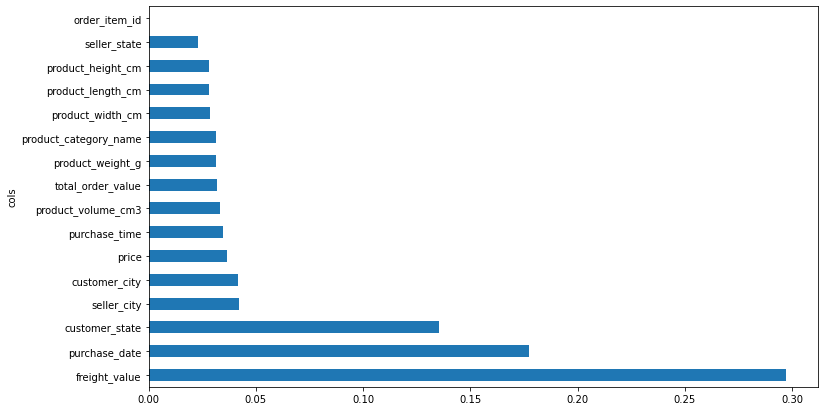

In [86]:
def plot_fi(fi): 
      return fi.plot('cols','imp','barh', figsize=(12,7),legend=False)

plot_fi(fi);

In [87]:
to_keep = fi[fi.imp>0.005].cols
to_keep

14            freight_value
5             purchase_date
2            customer_state
3               seller_city
4             customer_city
7                     price
6             purchase_time
15       product_volume_cm3
9         total_order_value
8          product_weight_g
0     product_category_name
12         product_width_cm
10        product_length_cm
11        product_height_cm
1              seller_state
Name: cols, dtype: object

In [88]:
len(to_keep) , len(fi)

(15, 16)

In [89]:
xs_imp = xs[to_keep]
valid_xs_imp = valid_xs[to_keep]

valid_xs_imp.columns.tolist()

['freight_value',
 'purchase_date',
 'customer_state',
 'seller_city',
 'customer_city',
 'price',
 'purchase_time',
 'product_volume_cm3',
 'total_order_value',
 'product_weight_g',
 'product_category_name',
 'product_width_cm',
 'product_length_cm',
 'product_height_cm',
 'seller_state']

In [90]:
m = rf(xs_imp, y)

m_rmse(m, xs_imp, y), m_rmse(m, valid_xs_imp, valid_y)

(0.257007, 0.403806)

In [91]:
xs_final = xs_imp
valid_xs_final = valid_xs_imp 

In [92]:
save_pickle('./xs_final.pkl', xs_final)
save_pickle('./valid_xs_final.pkl', valid_xs_final)

# Final Chosen Features

In [93]:
xs = load_pickle('./xs_final.pkl')
valid_xs = load_pickle('./valid_xs_final.pkl')

# make sure everything is going well

In [94]:
m = rf(xs,y)

m_rmse(m, xs, y), m_rmse(m, valid_xs, valid_y)

(0.257096, 0.402983)

# Water Fall 

how is the `xs` affecting the `y` {freight_value}

In [95]:
! pip install treeinterpreter waterfallcharts --quiet

In [96]:
import warnings
warnings.simplefilter('ignore', FutureWarning)

from treeinterpreter import treeinterpreter
from waterfall_chart import plot as waterfall

In [97]:
row = valid_xs.iloc[:10]
prediction,bias,contributions = treeinterpreter.predict(m,row.values)

In [98]:
prediction[2][0],bias[2],contributions[2].sum()

(2.8737214718738815, 2.349478815968585, 0.5242426559052966)

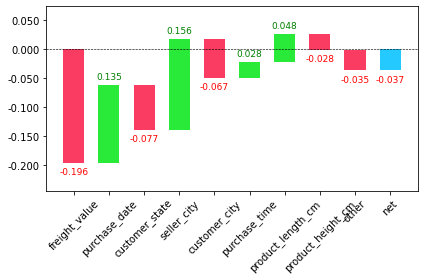

In [99]:

waterfall(
  valid_xs.columns, contributions[1], threshold=0.08,
  rotation_value=45, formatting='{:.3f}'
  );

# Testing The Random forest

In [100]:
dl_test = to.dataloaders().test_dl(test_df)
xs_test, y_test = dl_test.train.xs, dl_test.train.y
xs_test = xs_test[xs.columns.to_list()]

m_rmse(m,xs_test, y_test)

0.434073

this is amazing, the same as the validation result

# Neural Network 

In [118]:
df.shape

(97752, 17)

In [119]:
df_nn = df.copy()
df_nn_final = df_nn[xs.columns.to_list() + [dep_var]]

df_nn_final.shape

(97752, 16)

In [120]:
# 20% validation set
splits = RandomSplitter(valid_pct=0.2,seed=42)(range_of(df_nn_final))
len(splits[0]),len(splits[1])

(78202, 19550)

In [121]:
cont_nn, cat_nn = cont_cat_split(df_nn_final, max_card=9000, dep_var=dep_var)

In [122]:
df_nn_final[cat_nn].nunique()

purchase_date             612
customer_state             27
seller_city               581
customer_city            3955
purchase_time              24
product_category_name      71
seller_state               22
dtype: int64

In [123]:
procs_nn = [Categorify, FillMissing]
to_nn = TabularPandas(df_nn_final, procs_nn, cat_nn,
                      cont_nn, splits=splits, y_names=dep_var)

In [124]:
# our dataset is 509 , when i use 1024 of course it is empty! 
dls = to_nn.dataloaders(1024) # since tabular data do not use much GPU RAM

In [125]:
y = to_nn.train.y

y.min(),y.max()

(0.0, 3.4011974)

SuggestedLRs(valley=0.004365158267319202, slide=0.04786301031708717)

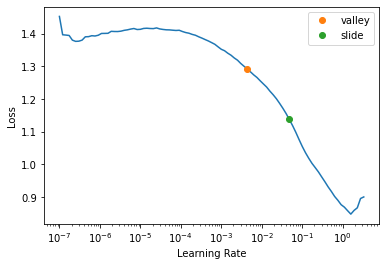

In [127]:
learn = tabular_learner(dls, y_range=(0,3.4), layers=[50,25,15,5],
                        n_out= 1, loss_func=F.mse_loss
                       )

learn.lr_find(suggest_funcs=(valley,slide))

In [151]:
learn = tabular_learner(dls, y_range=(0,3.4), layers=[50,25,15,5],
                        n_out= 1, loss_func=F.mse_loss
                       )

In [152]:
learn.fit_one_cycle(10, 1e-1) # weight decay

epoch,train_loss,valid_loss,time
0,0.230544,0.207358,00:00
1,0.195146,0.207767,00:00
2,0.180938,0.182814,00:00
3,0.172540,0.187451,00:00
4,0.163440,0.181449,00:00
5,0.155079,0.178325,00:00
6,0.145449,0.182955,00:01
7,0.133591,0.177557,00:01
8,0.121057,0.180065,00:00
9,0.111820,0.182922,00:00


In [153]:
preds, targets = learn.get_preds()

r_mse(preds, targets)

0.427694

# Testing the NN

In [154]:
dl_test = learn.dls.test_dl(test_df)

In [155]:
# the test set shows you how well you are doing
# i can say we are doing pretty well
preds , y = learn.get_preds(dl=dl_test)

In [156]:
r_mse(preds,y)

0.456536

In [157]:
save_pickle('./learn.pkl', learn)

very cool !

# Using XGBoost 

In [158]:
from xgboost import XGBRegressor

In [159]:
to = load_pickle('./to_olist.pkl')
y = to.train.y
valid_y = to.valid.y
xs = load_pickle('./xs_final.pkl')
valid_xs = load_pickle('./valid_xs_final.pkl')

In [160]:
def xgboost(xs,y,learning_rate=0.3, n_estimators=700,
                  max_depth=10, subsample=0.9, colsample_bytree=0.7,min_child_weight=3,**params):
      return XGBRegressor(random_state=42, n_jobs=-1, 
                       learning_rate= learning_rate, n_estimators= n_estimators,
                       max_depth=max_depth, subsample=subsample, colsample_bytree=colsample_bytree,
                       min_child_weight = min_child_weight, device='cuda').fit(xs,y)

In [161]:
m_rf = rf(xs,y)

In [162]:
# i think we can do better
# use more trees
xgb = xgboost(xs, y, learning_rate=0.1,
              n_estimators=1000, colsample_bytree=0.7, subsample=0.9,
              max_depth=10, min_child_weight=3)

[07:55:42] WARNING: ../src/learner.cc:627: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.




In [163]:
preds_xgb = xgb.predict(valid_xs)
preds_rf = m_rf.predict(valid_xs)

r_mse(preds_rf,valid_y),r_mse(preds_xgb,valid_y)

(0.403825, 0.386327)

# Testing XGBOOST

In [164]:
# TESTING THE BOOSTING AND BAGGING METHODS


dl_test = to.dataloaders().test_dl(test_df)
xs_test, y_test = dl_test.train.xs, dl_test.train.y
xs_test = xs_test[xs.columns.to_list()]

dl_test_nn = learn.dls.test_dl(test_df)



In [165]:
RF_test = m_rmse(m_rf, xs_test, y_test)
XBG_test = m_rmse(xgb, xs_test, y_test)

preds_nn , y_nn = learn.get_preds(dl=dl_test_nn)

NN_test = r_mse(preds_nn,y_nn)

print(f'Random Forest Test Result: { RF_test  }  || XGBOOST Test Result: { XBG_test } || NN Test Result: { NN_test } ')

Random Forest Test Result: 0.434842  || XGBOOST Test Result: 0.427737 || NN Test Result: 0.456536 


# Ensembling 

Ensembling - combining lots of models together to make a single prediction.

`5-year-old`: if more humans agree on a decision that decision is more likely to happen, and it is more likely to be right

In [166]:
nn_general_prediction = to_np(preds_nn.squeeze())

In [167]:
pred_rf = m_rf.predict(xs_test)
pred_xgb = xgb.predict(xs_test)

In [168]:
combined_preds = [pred_rf, pred_xgb,nn_general_prediction]
preds  = np.stack(combined_preds).mean(0)
r_mse(preds,y_test)

0.417426

In [169]:


combined_predictions = [
    pred_rf * 0.3,
    pred_xgb * 0.5,
    nn_general_prediction * 0.2
]

# Compute the weighted average
preds_weighted = np.sum(combined_predictions, axis=0)

# Calculate RMSLE of the ensemble
ensemble_rmsle = r_mse(preds_weighted, y_test)
print(f"Weighted Ensemble RMSLE: {ensemble_rmsle}")

Weighted Ensemble RMSLE: 0.417177


# Export the models

In [170]:
import joblib
export_data = dict(
    xgb = xgb,
    rf = m_rf,
    nn = learn
    
)

export_data

{'xgb': XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=0.7,
              device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, gamma=0, gpu_id=-1,
              grow_policy='depthwise', importance_type=None,
              interaction_constraints='', learning_rate=0.1, max_bin=256,
              max_cat_to_onehot=4, max_delta_step=0, max_depth=10, max_leaves=0,
              min_child_weight=3, missing=nan, monotone_constraints='()',
              n_estimators=1000, n_jobs=-1, num_parallel_tree=1,
              predictor='auto', random_state=42, reg_alpha=0, ...),
 'rf': RandomForestRegressor(max_features=0.7, max_samples=78202, min_samples_leaf=4,
                       n_estimators=70, n_jobs=-1, oob_score=True),
 'nn': <fastai.tabular.learner.TabularLearner at 0x7fd81b609610>}

In [171]:
joblib.dump(export_data, 'olist_learners.joblib')

['olist_learners.joblib']

# Load them back

In [172]:
data = joblib.load('./olist_learners.joblib')
data

{'xgb': XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=0.7,
              device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, gamma=0, gpu_id=-1,
              grow_policy='depthwise', importance_type=None,
              interaction_constraints='', learning_rate=0.1, max_bin=256,
              max_cat_to_onehot=4, max_delta_step=0, max_depth=10, max_leaves=0,
              min_child_weight=3, missing=nan, monotone_constraints='()',
              n_estimators=1000, n_jobs=-1, num_parallel_tree=1,
              predictor='auto', random_state=42, reg_alpha=0, ...),
 'rf': RandomForestRegressor(max_features=0.7, max_samples=78202, min_samples_leaf=4,
                       n_estimators=70, n_jobs=-1, oob_score=True),
 'nn': <fastai.tabular.learner.TabularLearner at 0x7fd8187de160>}